# Libraries

In [36]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, classification_report)

# Data
## Import Data

In [37]:
X = np.load('data/X.npy')
y = np.load('data/Y.npy')

N, K = X.shape
print(f"Observations: {N}, Variables: {K}")

Observations: 5881, Variables: 7


In [38]:
feature_names = [
    'frequency',
    'monetary_value',
    'cancellation_rate',
    'stockcode_diversity',
    'return_propensity',
    'avg_time_between_purchases',
    'is_uk'
]

## Data Check

In [39]:
print("y dtype:", y.dtype)
print("y unique values:", np.unique(y))
print("y shape:", y.shape)
print("X shape:", X.shape)
print("X has NaN:", np.isnan(X).any())
print("y has NaN:", np.isnan(y).any())

y dtype: int32
y unique values: [0 1]
y shape: (5881,)
X shape: (5881, 7)
X has NaN: False
y has NaN: False


## Standardization

In [40]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Bayesian probit Model

In [41]:
with pm.Model(coords={'features': feature_names}) as probit_model:
    
    # Non informative Prior
    beta = pm.MvNormal(
        'beta',
        mu = np.zeros(K),
        cov = 100*np.eye(K),
        shape = K,
        dims = 'features'
    )

    # Likelihood probit
    mu = pm.math.dot(X, beta)
    p = pm.math.invprobit(mu)
    y_obs = pm.Bernoulli('y_obs', p=p, observed = y)


# --- NUTS ---
print("Beginning the training...")

with probit_model:
    trace = pm.sample(
        draws = 1000, # samples after warmup
        tune = 1000, # warmup 
        chains = 4, # calibrate with Rhat !!!!!!!!
        cores = 1, # CPU cores
        target_accept = 0.95, # acceptance probability of target
        random_seed = 42, 
        return_inferencedata= True
    )

Initializing NUTS using jitter+adapt_diag...


Beginning the training...


Sequential sampling (4 chains in 1 job)
NUTS: [beta]


/Users/paolominini/Desktop/University/Bayesian 
Analysis/project/Churn_Model_Bayesian/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.


## Diagnostics

                                   mean     sd  hdi_3%  hdi_97%  mcse_mean  \
beta[frequency]                  -0.405  0.051  -0.497   -0.310      0.001   
beta[monetary_value]             -0.256  0.030  -0.313   -0.200      0.001   
beta[cancellation_rate]           0.053  0.020   0.019    0.092      0.000   
beta[stockcode_diversity]        -0.391  0.037  -0.463   -0.322      0.001   
beta[return_propensity]           0.052  0.024   0.009    0.098      0.000   
beta[avg_time_between_purchases] -0.173  0.018  -0.206   -0.138      0.000   
beta[is_uk]                       0.022  0.018  -0.012    0.055      0.000   

                                  mcse_sd  ess_bulk  ess_tail  r_hat  
beta[frequency]                     0.001    3660.0    2735.0    1.0  
beta[monetary_value]                0.000    3085.0    2782.0    1.0  
beta[cancellation_rate]             0.000    4209.0    3445.0    1.0  
beta[stockcode_diversity]           0.001    3511.0    2914.0    1.0  
beta[return_propensi

<Axes: >

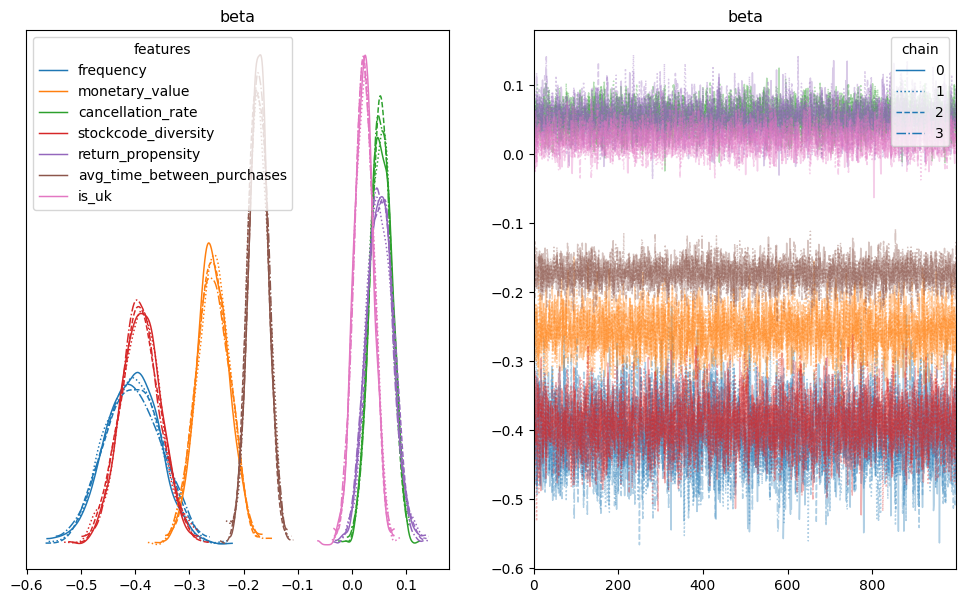

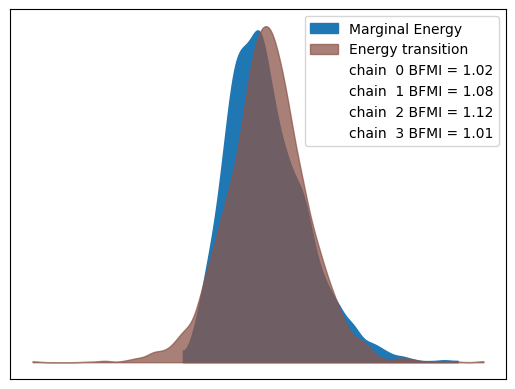

In [49]:
print(az.summary(trace, var_names = ['beta']))
print("Max R-hat:", float(az.rhat(trace)['beta'].max()))

az.plot_trace(trace, var_names = ['beta'], legend= True, figsize = (12, K))
az.plot_energy(trace)

# Predictions and Evaluation

In [43]:
beta_samples  = trace.posterior['beta'].values.reshape(-1, K)
y_pred_prob   = norm.cdf(X @ beta_samples.T).mean(axis=1)
y_class       = (y_pred_prob > 0.5).astype(int)

print("Accuracy :", accuracy_score(y, y_class))
print("ROC-AUC  :", roc_auc_score(y, y_pred_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_class))
print("\nClassification Report:\n", classification_report(y, y_class))

Accuracy : 0.713484101343309
ROC-AUC  : 0.7720104570362353

Confusion Matrix:
 [[1810  952]
 [ 733 2386]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.66      0.68      2762
           1       0.71      0.76      0.74      3119

    accuracy                           0.71      5881
   macro avg       0.71      0.71      0.71      5881
weighted avg       0.71      0.71      0.71      5881

